In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.preprocessing import KBinsDiscretizer

## Load data

In [2]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


In [37]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# Naive Bayes Classifier

## Base model

In [16]:
nb = BernoulliNB()
nb.fit(X_train, y_train)

BernoulliNB()

In [40]:
y_pred = nb.predict(X_test)
print(classification_report(y_test, y_pred))


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- child_weight_binned
Feature names seen at fit time, yet now missing:
- child_weight


### Average Precision Score

In [18]:
y_probas = nb.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.6057219756428966


## Hyperparameter Tuning

In [23]:
params = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0],   # Additive (Laplace) smoothing parameter
    'fit_prior': [True, False]              # Whether to learn class prior probabilities
}

nb_params = BernoulliNB()

# Grid Search
grid_search = GridSearchCV(
    estimator=nb_params,
    param_grid=params,
    scoring='recall', 
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit the model
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5, estimator=BernoulliNB(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1.0],
                         'fit_prior': [True, False]},
             scoring='recall', verbose=1)

In [24]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'alpha': 0.001, 'fit_prior': False}
Best Cross-Validation Accuracy: 0.6195976390854249


In [25]:
nb_tune = grid_search.best_estimator_
y_pred = nb_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.56      0.60       707
           1       0.54      0.63      0.58       579

    accuracy                           0.59      1286
   macro avg       0.59      0.60      0.59      1286
weighted avg       0.60      0.59      0.59      1286



## Average Precision

In [ ]:
y_probas = nb_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.6056198471948041


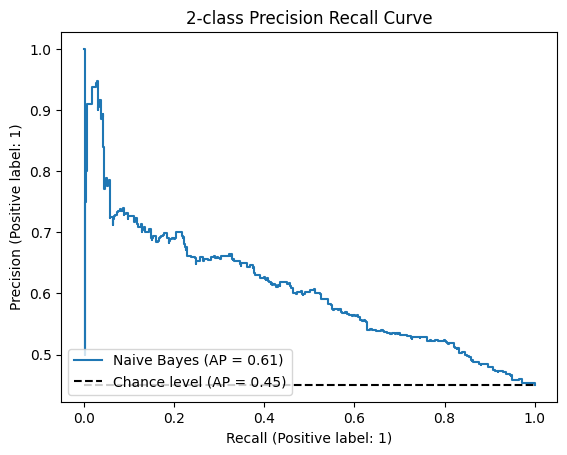

In [28]:
display = PrecisionRecallDisplay.from_estimator(
    nb_tune,
    X_test,
    y_test, 
    name="Naive Bayes",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### Confusion matrix

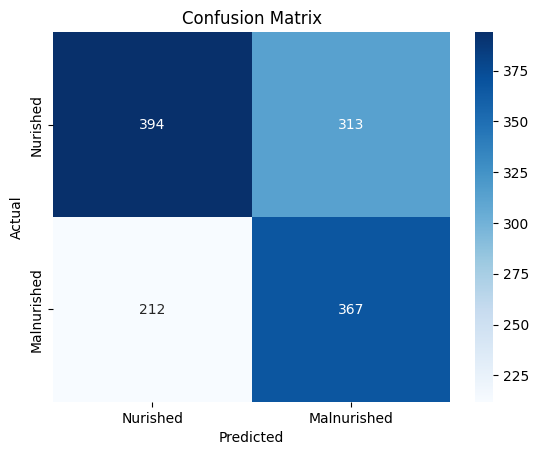

In [29]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Features importance

In [30]:
# Get log probability of features given class
feature_log_prob = nb_tune.feature_log_prob_

# Calculate absolute difference between classes as importance measure
importance = np.abs(feature_log_prob[1] - feature_log_prob[0])

# Create DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance,
    'Class 0 log prob': feature_log_prob[0],
    'Class 1 log prob': feature_log_prob[1]
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                   Feature    Importance  Class 0 log prob  Class 1 log prob
7         health_insurance  6.954369e-01     -2.847453e+00     -3.542890e+00
14            province_6.0  6.080126e-01     -2.483490e+00     -1.875477e+00
11            province_3.0  5.140368e-01     -1.490555e+00     -2.004591e+00
12            province_4.0  4.555812e-01     -1.983744e+00     -2.439325e+00
15            province_7.0  3.803411e-01     -2.267150e+00     -1.886809e+00
1             child_weight  3.516906e-01     -5.083536e-01     -8.600441e-01
9             province_1.0  2.694379e-01     -1.777713e+00     -2.047151e+00
10            province_2.0  2.469417e-01     -1.973514e+00     -1.726572e+00
2   diarrhoea_last_2_weeks  2.384924e-01     -2.413932e+00     -2.175440e+00
13            province_5.0  1.565194e-01     -1.950871e+00     -1.794352e+00
4                     area  1.490743e-01     -5.201810e-01     -6.692553e-01
6         mother_education  1.460177e-01     -2.175900e-01     -3.636076e-01

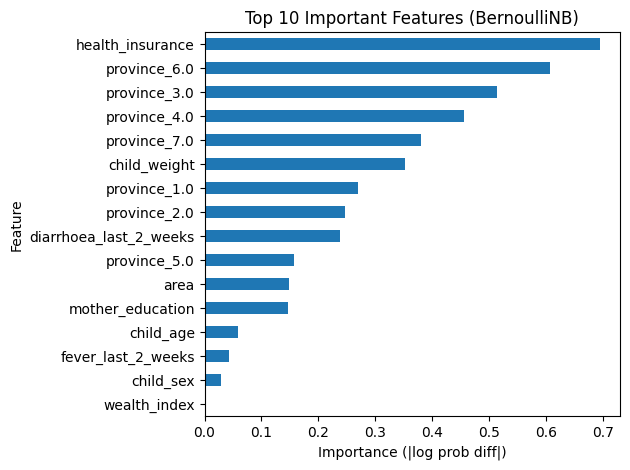

In [32]:
# Plot top 10 features
importance_df.head(17).plot(kind='barh', x='Feature', y='Importance', legend=False)
plt.title('Top 10 Important Features (BernoulliNB)')
plt.xlabel('Importance (|log prob diff|)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Multinomial Naive Bayes

Which is for all discretized variables

In [ ]:
df1 = df.copy()
child_weight_descretized = df1[['child_weight']]  # descretized child weight

# Initialize the discretizer
kbd = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')  

# Fit and transform
child_weight_binned = kbd.fit_transform(child_weight_descretized)

# Add back to DataFrame
df1['child_weight_binned'] = child_weight_binned.astype(int)
df1 = df1.drop(columns=['child_weight'])
df1.head(2)

c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(


,child_age,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0,child_weight_binned
0,1,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0,0
1,3,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0,1


In [4]:
X = df1.drop(columns=['malnurished'])
y = df1['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [5]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [7]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.67      0.65       707
           1       0.56      0.52      0.54       579

    accuracy                           0.60      1286
   macro avg       0.60      0.59      0.59      1286
weighted avg       0.60      0.60      0.60      1286



In [8]:
params = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0]
}

nb_params = MultinomialNB()

# Grid Search
grid_search = GridSearchCV(
    estimator=nb_params,
    param_grid=params,
    scoring='recall', 
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit the model
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1.0]},
             scoring='recall', verbose=1)

In [9]:
nb_tune = grid_search.best_estimator_
y_pred = nb_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.67      0.65       707
           1       0.56      0.52      0.54       579

    accuracy                           0.60      1286
   macro avg       0.60      0.59      0.59      1286
weighted avg       0.60      0.60      0.60      1286

